In [56]:
import pandas as pd

In [ ]:
train = pd.read_csv('data/train.csv')
print(train.head(5))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [58]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [59]:
test = pd.read_csv('data/test.csv')
print(test.head(5))

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


#### Punto 2.
El dataset de Test no tiene la variable "survived" porque esta variable es de prediccion y no queremos que nuestro modelo aprenda de memoria al predecir

In [60]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [61]:
data_dict = {
    "Variable": ["PassengerId", "Survived", "Pclass", "Name", "Sex", "Age", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"],
    "Descripción": [
        "Identificador único",
        "0 = No sobrevivió, 1 = Sobrevivió",
        "1 = 1ª Clase, 2 = 2ª Clase, 3 = 3ª Clase",
        "Nombre y título",
        "Género",
        "Edad en años",
        "Nº de hermanos/cónyuges a bordo",
        "Nº de padres/hijos a bordo",
        "Número del ticket",
        "Tarifa pagada",
        "Número de camarote",
        "Puerto de embarque (C, Q, S)"
    ]
}


df_diccionario = pd.DataFrame(data_dict)


print("Diccionario de datos del Titanic:")
display(df_diccionario)

Diccionario de datos del Titanic:


,Variable,Descripción
0,PassengerId,Identificador único
1,Survived,"0 = No sobrevivió, 1 = Sobrevivió"
2,Pclass,"1 = 1ª Clase, 2 = 2ª Clase, 3 = 3ª Clase"
3,Name,Nombre y título
4,Sex,Género
5,Age,Edad en años
6,SibSp,Nº de hermanos/cónyuges a bordo
7,Parch,Nº de padres/hijos a bordo
8,Ticket,Número del ticket
9,Fare,Tarifa pagada


#### Punto 3
Comparacion de variables:

* Se puede ver que ambos dataframes, el de test y el de train, son bastanantes parecidos:
* En la edad el promedio es casi igual en ambos dataframes, igual en las tarifas
* Tenemos datos incompletos en ambos dataframes, por ejemplo en edad nos faltan datos en ambos
* En test no existe la columna survive

In [62]:
# Estadísticas del set de entrenamiento
print("Estadisticas descriptivas de TRAIN:")
display(train.describe())

print("\n--------------------------------------------------\n")

# Estadísticas del set de prueba
print("Estadisticas descriptivas de TEST:")
display(test.describe())

Estadisticas descriptivas de TRAIN:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--------------------------------------------------

Estadisticas descriptivas de TEST:


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


#### Punto 4
SibSp: Es el número de hermanos o cónyuges

Parch: Es el numero de padres e hijos

¿Que opinamos de esta nueva variable?

Respuesta: Es mejor crear esta nueva variable ya que podemos simplificar las variables, asi podemos saber simplemente si viaja con alguien o viaja solo. Con una sola variable, al momento de predecir podria ser mejor tener menos variables

In [63]:
train['Familiares']= train['SibSp'] + train['Parch']
test['Familiares']= train['SibSp'] + train['Parch']
print(train[['SibSp', 'Parch', 'Familiares']].sample(10))

     SibSp  Parch  Familiares
507      0      0           0
175      1      1           2
214      1      0           1
806      0      0           0
497      0      0           0
229      3      1           4
2        0      0           0
881      0      0           0
706      0      0           0
786      0      0           0


#### punto 5.
Se dejaran sus valores NaN, no se debe borrar ya que permite identificar las filas de prueba y representa la variable que queremos predecir mas adelante

In [64]:
train['source'] = 'train'
test['source'] = 'test'

# pd.concat' las pega verticalmente
# ignore_index=True' rearma la numeración de las filas desde 0

datos_totales=pd.concat([train, test], ignore_index=True)
print(datos_totales)

      PassengerId  Survived  Pclass  \
0               1       0.0       3   
1               2       1.0       1   
2               3       1.0       3   
3               4       1.0       1   
4               5       0.0       3   
...           ...       ...     ...   
1304         1305       NaN       3   
1305         1306       NaN       1   
1306         1307       NaN       3   
1307         1308       NaN       3   
1308         1309       NaN       3   

                                                   Name     Sex   Age  SibSp  \
0                               Braund, Mr. Owen Harris    male  22.0      1   
1     Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                                Heikkinen, Miss. Laina  female  26.0      0   
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                              Allen, Mr. William Henry    male  35.0      0   
...                                                

#### punto 6
Despues de unir los dos conjuntos, la columna Survived se mantiene en el DataFrame final, para las filas que vienen de 'Test' Pandas les asignara automaticamente valores vacios, y eso esta bien porque no sabemos cuales sobrevivieron, entonces se dejara tal cual

In [65]:
estadisticas_comparadas = datos_totales.groupby('source').describe()
print(datos_totales.groupby('source')['Age'].describe())
print(datos_totales.groupby('source')['Fare'].describe())

        count       mean        std   min     25%   50%   75%   max
source                                                             
test    332.0  30.272590  14.181209  0.17  21.000  27.0  39.0  76.0
train   714.0  29.699118  14.526497  0.42  20.125  28.0  38.0  80.0
        count       mean        std  min     25%      50%   75%       max
source                                                                   
test    417.0  35.627188  55.907576  0.0  7.8958  14.4542  31.5  512.3292
train   891.0  32.204208  49.693429  0.0  7.9104  14.4542  31.0  512.3292


#### Punto 7.
Tras analizar el conjunto de datos, se identificó que las variables con datos faltantes son: Cabin (77.46%)
Survived (31.93% —correspondiente exactamente al test que no incluía esta variable—), Age (20.09%), Embarked (0.15%) y Fare (0.08%). La columna con mayor ausencia de información es Cabin (Cabina), la cual representa el número de camarote asignado al pasajero. En este contexto, el alto porcentaje de datos faltantes significa que no existió un registro exhaustivo de los camarotes para todas las clases, siendo una información casi exclusiva de los pasajeros de Primera Clase. Para el resto de los tripulantes y pasajeros (especialmente Tercera Clase), esta información es desconocida o se perdió durante el naufragio.

In [66]:
# Muestra la cantidad exacta de valores nulos por cada columna
print(datos_totales.isnull().sum())
print("----------------------")
# Muestra el porcentaje de datos faltantes
print((datos_totales.isnull().sum() / len(datos_totales)) * 100)


PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
Familiares        0
source            0
dtype: int64
----------------------
PassengerId     0.000000
Survived       31.932773
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
Familiares      0.000000
source          0.000000
dtype: float64


#### Punto 8

A : Edad Promedio

In [67]:
print(train['Age'].mean())


29.69911764705882


B : Sobrevivieron y murieron

In [68]:
print(train['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


C :  Tarifa promedio primera clase

In [69]:
print(train[train['Pclass'] == 1]['Fare'].mean())

84.1546875


D : Pasajeros con familiar a bordo

In [70]:
con_familiar = train[train['Familiares'] > 0]
print(f"Pasajeros con familiar: {len(con_familiar)}")

Pasajeros con familiar: 354


E : Edad más joven y más vieja

In [71]:
print(f"Edad más joven: {train['Age'].min()} años")
print(f"Edad más vieja: {train['Age'].max()} años")

Edad más joven: 0.42 años
Edad más vieja: 80.0 años


F : Pasajeros por puerto

In [72]:
print(train['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


G : Solos vs con familiares

In [73]:
solos = train[train['Familiares'] == 0]
con_familia = train[train['Familiares'] > 0]
print(f"Viajaron solos: {len(solos)}")
print(f"Viajaron con familiares: {len(con_familia)}")

Viajaron solos: 537
Viajaron con familiares: 354


#### Punto 9

A : Sobrevivieron mas mujeres que hombres, tanto en cantidad como proporcionalmente, porque en el Titanic se priorizó evacuar primero a mujeres y niños

In [74]:
supervivencia_sexo = train.groupby('Sex')['Survived'].agg(['sum', 'mean'])
supervivencia_sexo.columns = ['Total_sobrevivientes', 'Proporcion']
print(supervivencia_sexo)

        Total_sobrevivientes  Proporcion
Sex                                     
female                   233    0.742038
male                     109    0.188908


B : Creo que sobrevivieron más niños proporcionalmente por la misma razón, se les dio prioridad en los botes salvavidas.

In [75]:
tabla_9b = train.groupby('Sex')['Survived'].agg(['sum', 'mean'])
tabla_9b.columns = ['Total', 'Proporcion']
print(tabla_9b)

        Total  Proporcion
Sex                      
female    233    0.742038
male      109    0.188908


C : Creo que sí sobrevivieron más, los niños por prioridad de evacuación y los mayores posiblemente viajaban en clases más altas

In [76]:
tabla_9c = train.groupby('Pclass')['Survived'].agg(['sum', 'mean'])
tabla_9c.columns = ['Total', 'Proporcion']
print(tabla_9c)

        Total  Proporcion
Pclass                   
1         136    0.629630
2          87    0.472826
3         119    0.242363


D : Creo que en cantidad sí salieron más de Southampton porque era el puerto principal, pero proporcionalmente no necesariamente

In [77]:
supervivencia_puerto = train.groupby('Embarked')['Survived'].agg(['sum', 'mean'])
supervivencia_puerto.columns = ['Total', 'Proporcion']
print(supervivencia_puerto)

          Total  Proporcion
Embarked                   
C            93    0.553571
Q            30    0.389610
S           217    0.336957


E : Creo que los de primera clase sobrevivieron más proporcionalmente porque tenían mejor acceso a los botes al estar en cubiertas superiores 

In [78]:
supervivencia_clase = train.groupby('Pclass')['Survived'].agg(['sum', 'mean'])
supervivencia_clase.columns = ['Total', 'Proporcion']
print(supervivencia_clase)

        Total  Proporcion
Pclass                   
1         136    0.629630
2          87    0.472826
3         119    0.242363


#### Punto 10

Grupos familiares y distribución de cabinas

La mayoría de pasajeros sin familiares y con familias pequeñas 
no tenían cabina asignada (NaN). Las familias grandes tampoco 
tenían muchas cabinas registradas.

In [79]:
# Crear los grupos familiares
def grupo_familiar(f):
    if f == 0:
        return 'Grupo 1: Sin familiares'
    elif f <= 3:
        return 'Grupo 2: Familia pequeña'
    else:
        return 'Grupo 3: Familia grande'

train['grupo_familiar'] = train['Familiares'].apply(grupo_familiar)

# Distribución de cabinas por grupo
print(train.groupby('grupo_familiar')['Cabin'].value_counts())

grupo_familiar            Cabin          
Grupo 1: Sin familiares   D                  3
                          E101               3
                          F33                3
                          B28                2
                          B35                2
                                            ..
Grupo 2: Familia pequeña  E50                1
                          E68                1
                          F E69              1
Grupo 3: Familia grande   C23 C25 C27        4
                          B57 B59 B63 B66    2
Name: count, Length: 150, dtype: int64


#### Punto 11

Proporción de supervivencia por sexo, grupo etario y cabina

Los datos muestran que las mujeres sobrevivieron más en todos los 
grupos etarios. Los pasajeros con cabina asignada tuvieron mayor 
tasa de supervivencia, lo que sugiere que viajar en clases superiores 
aumentaba las probabilidades de sobrevivir.

In [80]:
# Crear grupo etario
def grupo_etario(age):
    if age < 10:
        return 'Niño'
    elif age < 50:
        return 'Adulto'
    else:
        return 'Mayor'

train['grupo_etario'] = train['Age'].apply(grupo_etario)

# Crear columna tiene_cabina
train['tiene_cabina'] = train['Cabin'].notna()

# Tabla de proporción
tabla = train.groupby(['grupo_etario', 'Sex', 'tiene_cabina'])['Survived'].mean()
print(tabla)

grupo_etario  Sex     tiene_cabina
Adulto        female  False           0.644928
                      True            0.971831
              male    False           0.122517
                      True            0.447761
Mayor         female  False           0.679245
                      True            0.909091
              male    False           0.098592
                      True            0.264706
Niño          female  False           0.653846
                      True            0.500000
              male    False           0.500000
                      True            1.000000
Name: Survived, dtype: float64


#### Punto 12

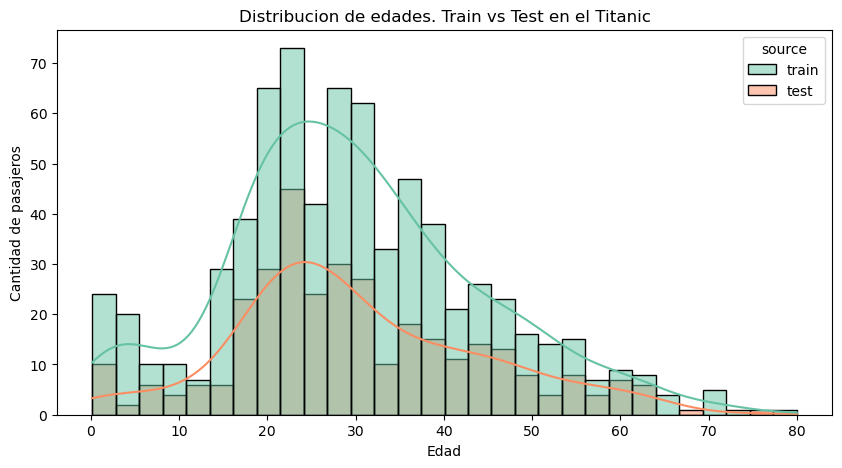

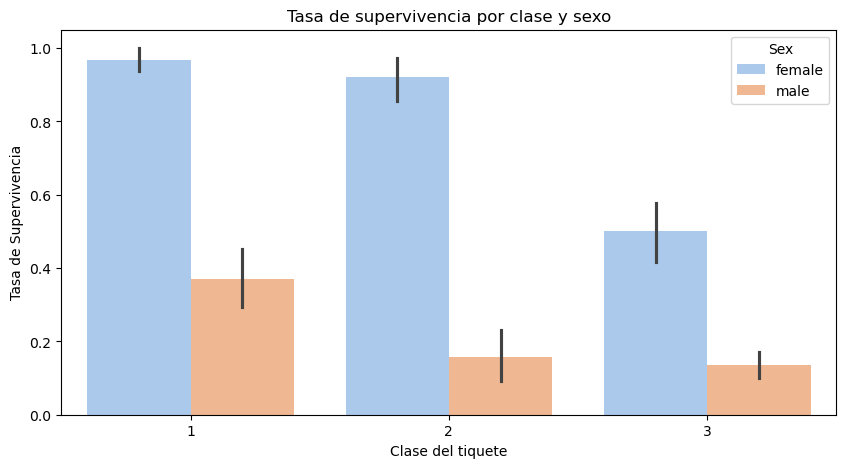

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1
plt.figure(figsize=(10, 5))
sns.histplot(data=datos_totales, x="Age", hue="source", kde=True, bins=30, palette="Set2")
plt.title("Distribucion de edades. Train vs Test en el Titanic")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")
plt.show()

# 2
plt.figure(figsize=(10, 5))
sns.barplot(data=train, x="Pclass", y="Survived", hue="Sex", palette="pastel")
plt.title("Tasa de supervivencia por clase y sexo")
plt.xlabel("Clase del tiquete")
plt.ylabel("Tasa de Supervivencia")
plt.show()

### Analisis de graficos

1. Grafico de distribucion de edades:
Al comparar la distribución de las edades en ambos conjuntos de datos (train y test), podemos observar que la distribucion de las dos son muy parecidas, las dos concentran sus datos en el rango de 20 y 30 años esto es muy importante al momento de interpretar por que nos dice que los dos grupos de datos son representativos entre si, el conjunto test es altamente representativo de train, asi que se que al de hacer un modelo predictivo al tener poblaciones iguales va a ser justo  entonces va a ser mas preciso.

2. Grafico de tasa de supervivencia por clase y Sexo:
Este grafico nos muestra la clara desigualdad que hay entre clases y sexo en el barco. Se puede observar que las personas con mayor tasa de supervivencia son las mujeres que viajaban en primera y segunda clase. Mientras se puede ver que en tercera clase y mas por parte de hombres baja extremadamente esta tasa de supervivencia. Esto nos dice que el protocolo de seguridad del barco priorizo claramente a las personas que pagaron mas y si eran mujeres o niños.

#### Punto 13

¿QUIEN TENIA MAS PROBABILIDADES DE SOBREVIVIR?

Para determinar qué perfil tenía mayores probabilidades de sobrevivir, analizamos los datos bajo el concepto de probabilidad condicional. Es decir, calculamos la probabilidad de supervivencia  dado un conjunto de condiciones especificas (genero y clase).Matemáticamente, lo que hace nuestro modelo al agrupar los datos en Pandas es calcular la siguiente probabilidad :

- P(S(G n C))  

- S=El pasajero sobrevive
- C= La clase del tiquete (C1, C2, C3).
- G= El genero (F:femenino,M:masculino)

Al evaluar el espacio muestral completo, encontramos que la intersección con la probabilidad de exito mas alta se da en el evento de ser mujer en primera clase:

- P(S (F n C1))  = 0.96

Ya con esto queda demostrado que dado que un pasajero fuera mujer y estubiera en primera clase su probabilidad de sobrevivir era del 96%.


Basándonos en este analisis, el perfil con la mayor probabilidad matemática de sobrevivir al hundimiento del Titanic era una mujer, que viajara en Primera Clase y que tuviera una cabina asignada.

Los datos demuestran que las mujeres de Primera Clase superaron el 96% de tasa de supervivencia. Por el otro lado, los pasajeros con la probabilidad más baja fueron los hombres adultos que viajaban en tercera clase . El estatus del tiquete y el género fueron los factores que hicieron que la gente obtuviera mas probabilidades de sobrevivir o no 